In [1]:

import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:

df = pd.read_csv(r"C:\Users\Nese\Desktop\joyRideAI\merged_output_ready.csv")

print(" Veri yüklendi")
print(df.columns)
df.head()


 Veri yüklendi
Index(['timestamp', 'ADALAR_BOSTANCI', 'ADALAR_BURGAZADA', 'ADALAR_BUYUKADA',
       'ADALAR_HEYBELIADA', 'ADALAR_KARTAL', 'ADALAR_KINALIADA',
       'ADALAR-BOSTANCI_BURGAZADA', 'ADALAR-BOSTANCI_BUYUKADA',
       'ADALAR-BOSTANCI_HEYBELIADA',
       ...
       'YENIKAPI - HAVALIMANI_UCYUZLU', 'YENIKAPI - HAVALIMANI_ULUBATLI',
       'YENIKAPI - HAVALIMANI_YENIBOSNA', 'YENIKAPI - HAVALIMANI_YENIKAPI',
       'YENIKAPI - HAVALIMANI_ZEYTINBURNU', 'YENIKAPI-ADALAR_YENI KABATAS',
       'YENIKOY-BEYKOZ_YENIKOY', 'day_of_week', 'month', 'hour'],
      dtype='object', length=484)


,timestamp,ADALAR_BOSTANCI,ADALAR_BURGAZADA,ADALAR_BUYUKADA,ADALAR_HEYBELIADA,ADALAR_KARTAL,ADALAR_KINALIADA,ADALAR-BOSTANCI_BURGAZADA,ADALAR-BOSTANCI_BUYUKADA,ADALAR-BOSTANCI_HEYBELIADA,...,YENIKAPI - HAVALIMANI_UCYUZLU,YENIKAPI - HAVALIMANI_ULUBATLI,YENIKAPI - HAVALIMANI_YENIBOSNA,YENIKAPI - HAVALIMANI_YENIKAPI,YENIKAPI - HAVALIMANI_ZEYTINBURNU,YENIKAPI-ADALAR_YENI KABATAS,YENIKOY-BEYKOZ_YENIKOY,day_of_week,month,hour
0,2023-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.081545,0.0,0.158055,...,0.018507,0.032043,0.005076,0.171894,0.042054,0.0,0.0,6,1,0
1,2023-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.115880,0.0,0.000000,...,0.008945,0.011126,0.002307,0.236534,0.035850,0.0,0.0,6,1,1
2,2023-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.012876,0.0,0.051672,...,0.004010,0.016021,0.000461,0.162742,0.035505,0.0,0.0,6,1,2
3,2023-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.001542,0.005340,0.000461,0.108590,0.071699,0.0,0.0,6,1,3
4,2023-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,...,0.002468,0.006676,0.001384,0.051578,0.015857,0.0,0.0,6,1,4


In [4]:
# %%
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Başlangıç:", df["timestamp"].min())
print("Bitiş    :", df["timestamp"].max())
print("Toplam satır:", len(df))


Başlangıç: 2023-01-01 00:00:00
Bitiş    : 2023-12-31 23:00:00
Toplam satır: 8739


In [5]:
# %%
TARGET_ROUTE = "YENIKAPI - HAVALIMANI_YENIKAPI"

route_df = df[[
    "timestamp",
    TARGET_ROUTE,
    "hour",
    "day_of_week",
    "month"
]].copy()

route_df.rename(columns={TARGET_ROUTE: "density"}, inplace=True)

route_df.head()


,timestamp,density,hour,day_of_week,month
0,2023-01-01 00:00:00,0.171894,0,6,1
1,2023-01-01 01:00:00,0.236534,1,6,1
2,2023-01-01 02:00:00,0.162742,2,6,1
3,2023-01-01 03:00:00,0.108590,3,6,1
4,2023-01-01 04:00:00,0.051578,4,6,1


In [6]:
# %%
route_df["density_t_plus_1h"] = route_df["density"].shift(-1)
route_df.dropna(inplace=True)

route_df[["timestamp", "density", "density_t_plus_1h"]].head()


,timestamp,density,density_t_plus_1h
0,2023-01-01 00:00:00,0.171894,0.236534
1,2023-01-01 01:00:00,0.236534,0.162742
2,2023-01-01 02:00:00,0.162742,0.108590
3,2023-01-01 03:00:00,0.108590,0.051578
4,2023-01-01 04:00:00,0.051578,0.044046


In [7]:
# %%
feature_cols = ["hour", "day_of_week", "month", "density"]
target_col = "density_t_plus_1h"

X = route_df[feature_cols]
y = route_df[target_col]

print(X.shape, y.shape)


(8738, 4) (8738,)


In [8]:
# %%
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [9]:
# %%
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05
    ))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE : 0.0576
RMSE: 0.0773


In [10]:
# %%
def best_departure_time(current_row, model, max_wait=3):

    results = []
    base_density = current_row["density"]

    for h in range(max_wait + 1):
        future_hour = (current_row["hour"] + h) % 24

        X_future = [[
            future_hour,
            current_row["day_of_week"],
            current_row["month"],
            base_density
        ]]

        pred_density = model.predict(X_future)[0]

        results.append({
            "wait_hours": h,
            "predicted_density": round(pred_density, 4)
        })

    return pd.DataFrame(results)


In [11]:
# %%
sample_row = route_df.iloc[1000]

decision_df = best_departure_time(sample_row, svm_model)
decision_df


c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,wait_hours,predicted_density
0,0,0.4360
1,1,0.3761
2,2,0.3087
3,3,0.2365


In [12]:
# %%
def decision_text(decision_df):

    best_row = decision_df.loc[
        decision_df["predicted_density"].idxmin()
    ]

    wait = int(best_row["wait_hours"])
    best_density = best_row["predicted_density"]
    now_density = decision_df.loc[0, "predicted_density"]

    improvement = (now_density - best_density) / now_density * 100

    if wait == 0:
        return "🚦 Şu anda çıkmak en uygun zaman."

    return (
        f"⏳ {wait} saat sonra yola çıkarsanız "
        f"yoğunluk yaklaşık %{improvement:.1f} azalıyor."
    )

print(decision_text(decision_df))


⏳ 3 saat sonra yola çıkarsanız yoğunluk yaklaşık %45.8 azalıyor.


In [13]:
# %%
def minute_level_decision(decision_df, minute_steps=[15, 30, 45]):

    rows = []

    now_density = decision_df.loc[0, "predicted_density"]
    next_density = decision_df.loc[1, "predicted_density"]

    for m in minute_steps:
        ratio = m / 60
        interpolated_density = (
            now_density * (1 - ratio) + next_density * ratio
        )

        rows.append({
            "wait_minutes": m,
            "predicted_density": round(interpolated_density, 4)
        })

    return pd.DataFrame(rows)


minute_df = minute_level_decision(decision_df)
minute_df


,wait_minutes,predicted_density
0,15,0.4210
1,30,0.4060
2,45,0.3911


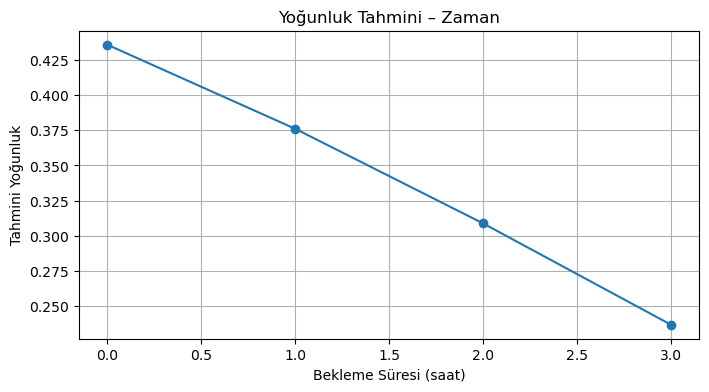

In [14]:
# %%
import matplotlib.pyplot as plt

def plot_density_forecast(decision_df):

    plt.figure(figsize=(8, 4))
    plt.plot(
        decision_df["wait_hours"],
        decision_df["predicted_density"],
        marker="o"
    )

    plt.xlabel("Bekleme Süresi (saat)")
    plt.ylabel("Tahmini Yoğunluk")
    plt.title("Yoğunluk Tahmini – Zaman")
    plt.grid(True)
    plt.show()


plot_density_forecast(decision_df)


In [15]:
# %%
routes = [
    "YENIKAPI - HAVALIMANI_YENIKAPI",
    "YENIKAPI - HAVALIMANI_ZEYTINBURNU",
    "YENIKAPI - HAVALIMANI_YENIBOSNA"
]

def compare_routes(df, routes, model, row_index=1000):

    results = []

    for route in routes:
        temp_df = df[[
            "timestamp", route, "hour", "day_of_week", "month"
        ]].copy()

        temp_df.rename(columns={route: "density"}, inplace=True)

        current_row = temp_df.iloc[row_index]

        X = [[
            current_row["hour"],
            current_row["day_of_week"],
            current_row["month"],
            current_row["density"]
        ]]

        pred_density = model.predict(X)[0]

        results.append({
            "route": route,
            "predicted_density": round(pred_density, 4)
        })

    return pd.DataFrame(results).sort_values("predicted_density")


compare_df = compare_routes(df, routes, svm_model)
compare_df


c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Nese\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,route,predicted_density
2,YENIKAPI - HAVALIMANI_YENIBOSNA,0.203
1,YENIKAPI - HAVALIMANI_ZEYTINBURNU,0.384
0,YENIKAPI - HAVALIMANI_YENIKAPI,0.436


In [17]:
# %%
def route_decision_text(compare_df):

    best = compare_df.iloc[0]
    worst = compare_df.iloc[-1]

    improvement = (
        (worst["predicted_density"] - best["predicted_density"])
        / worst["predicted_density"] * 100
    )

    return (
        f" En konforlu rota: {best['route']}\n"
        f" Yoğunluk farkı: %{improvement:.1f} daha az\n"
        f" Kaçınılması önerilen rota: {worst['route']}"
    )


print(route_decision_text(compare_df))


 En konforlu rota: YENIKAPI - HAVALIMANI_YENIBOSNA
 Yoğunluk farkı: %53.4 daha az
 Kaçınılması önerilen rota: YENIKAPI - HAVALIMANI_YENIKAPI


In [18]:
# %%
def density_to_class(d):
    if d < 0.33:
        return "Rahat"
    elif d < 0.66:
        return "Orta"
    else:
        return "Yogun"


y_pred_reg = y_pred
y_true_reg = y_test.values

y_pred_cls = [density_to_class(v) for v in y_pred_reg]
y_true_cls = [density_to_class(v) for v in y_true_reg]


In [19]:
# %%
from sklearn.metrics import classification_report

print(classification_report(
    y_true_cls,
    y_pred_cls,
    digits=3
))


              precision    recall  f1-score   support

        Orta      0.572     0.883     0.694       349
       Rahat      0.981     0.844     0.908      1257
       Yogun      0.837     0.761     0.797       142

    accuracy                          0.845      1748
   macro avg      0.797     0.829     0.800      1748
weighted avg      0.888     0.845     0.856      1748



In [20]:
# %%
from sklearn.metrics import confusion_matrix

class_names = ["Rahat", "Orta", "Yogun"]

cm = confusion_matrix(
    y_true_cls,
    y_pred_cls,
    labels=class_names
)

cm_df = pd.DataFrame(
    cm,
    index=["Gerçek_Rahat", "Gerçek_Orta", "Gerçek_Yogun"],
    columns=["Tahmin_Rahat", "Tahmin_Orta", "Tahmin_Yogun"]
)

cm_df


,Tahmin_Rahat,Tahmin_Orta,Tahmin_Yogun
Gerçek_Rahat,1061,196,0
Gerçek_Orta,20,308,21
Gerçek_Yogun,0,34,108


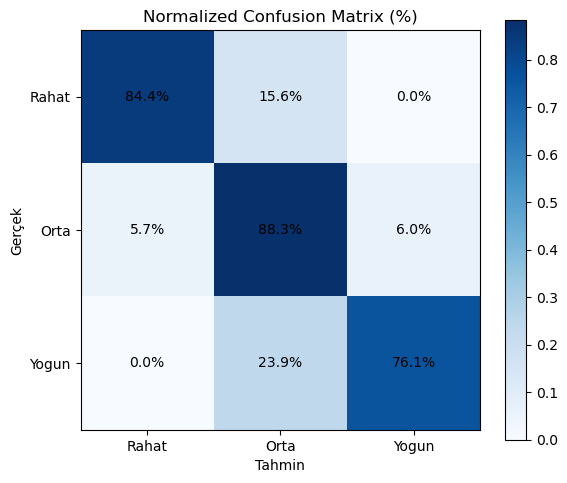

In [21]:
# %%
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues")
plt.title("Normalized Confusion Matrix (%)")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j, i, f"{cm_norm[i, j]*100:.1f}%",
            ha="center", va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()
